Loading universe, benchmark, and sector factors...


$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")


Universe: 461 tickers | 2015-01-02 – 2023-12-29

Running PortfolioStudy with 4 strategies...



event_driven_v26:   0%|                                                                                                                            | 0/12 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...



resid_mr_v10:   0%|                                                                                                                                | 0/14 [00:00<?, ?it/s, stage=residualize]

Using factors for residuals...



coint_mr_v28:   7%|████████▍                                                                                                             | 1/14 [00:00<00:00, 1150.39it/s, stage=base_signal]$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

combined_4_strategy_portfolio: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:23<00:00,  3.41s/it, stage=metrics]



  Portfolio: combined_4_strategy_portfolio

sharpe                              1.380102
ann_return                          0.217966
ann_vol                              0.15122
max_drawdown                         -0.2238
max_drawdown_duration                    114
max_drawdown_start       2018-01-23 00:00:00
max_drawdown_end         2018-07-05 00:00:00
avg_daily_turnover                  0.512698
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.834783
information_ratio                   0.812194

--- Strategy Return Correlations ---
                  event_driven_v26  momentum_v19  resid_mr_v10  coint_mr_v28
event_driven_v26          1.000000      0.580415      0.059225      0.384509
momentum_v19              0.580415      1.000000      0.066231      0.399424
resid_mr_v10              0.059225      0.066231      1.000000      0.020790
coint_mr_v28              0.384509      0.399424      0.020790      1

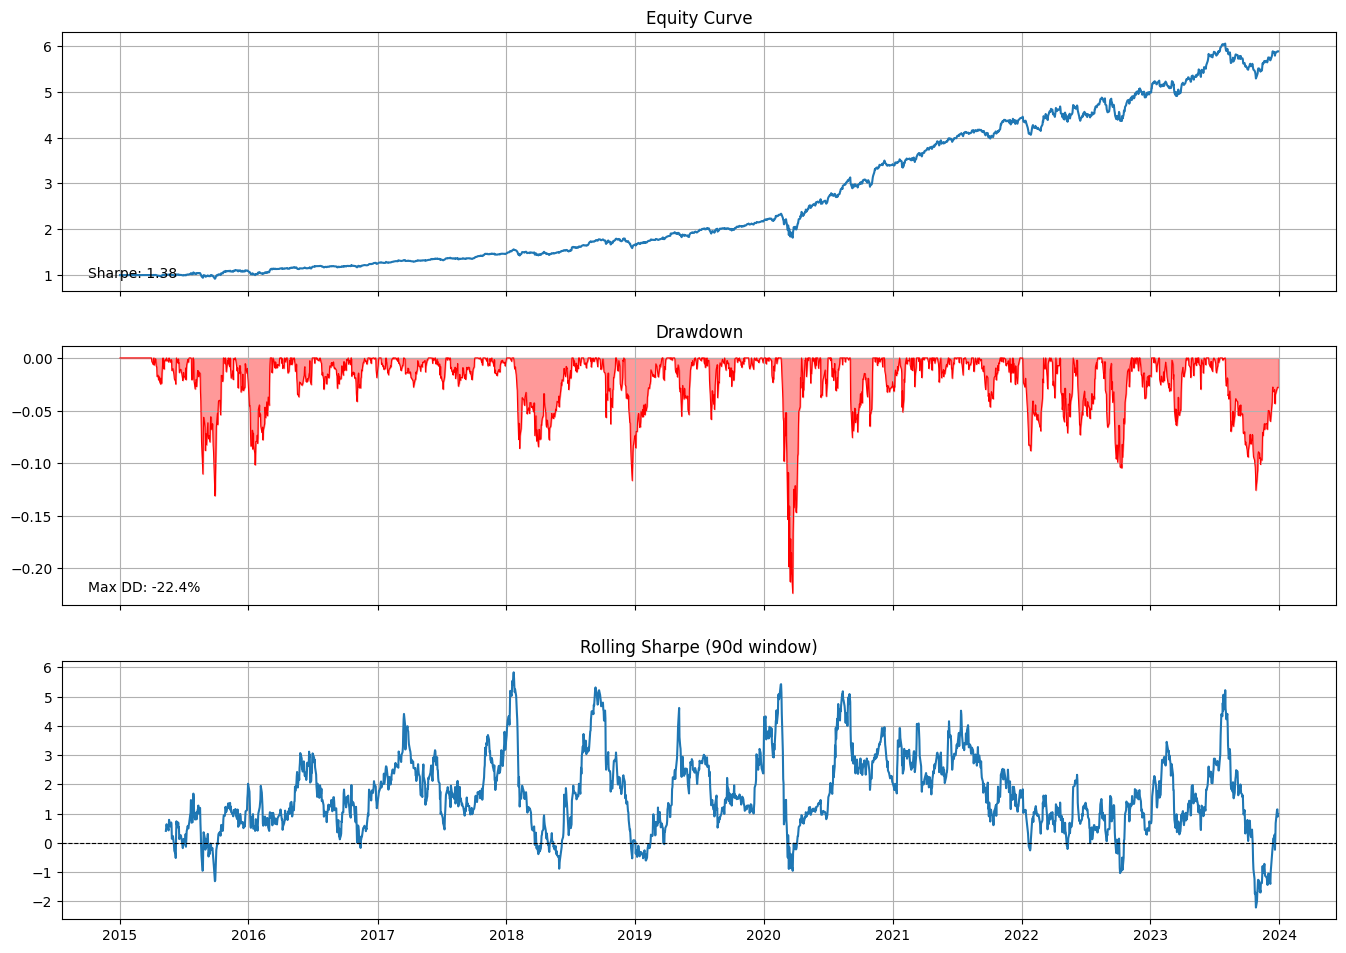


--- Individual Strategy Metrics ---
  event_driven_v26           sharpe=+1.01  ret=+23.6%  dd=-30.4%
  momentum_v19               sharpe=+1.00  ret=+21.1%  dd=-38.0%
  resid_mr_v10               sharpe=+0.81  ret=+7.2%  dd=-9.0%
  coint_mr_v28               sharpe=+1.49  ret=+19.9%  dd=-14.3%

--- Portfolio Metrics ---
  Sharpe:      +1.38
  Ann Return:  +21.8%
  Ann Vol:     15.1%
  Max DD:      -22.4%
  DD Duration: 114 days
  Info Ratio:  +0.81
  Benchmark Corr: 0.83


In [6]:
"""Combined portfolio study: event-driven + momentum + residual MR + cointegration MR.

Combines four independently developed strategies into a single PortfolioStudy:

    1. event_driven_v26   — volume shock continuation (zscore, liquidity top 150)
    2. momentum_v19       — benchmark-relative momentum, volume confirmed, long-only
    3. resid_mr_v10       — residual mean reversion, proportional positions, dual regime
    4. coint_mr_v28       — two-factor residual MR (market+sector beta stripped), beta-neutral

Each strategy pipeline is defined without data or .run() so PortfolioStudy can inject
the shared universe/benchmark and run them all on the same aligned dataset.

Usage:
    uv run python docs/combined_portfolio_study.py
"""

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Make experiment common modules importable by name
# __file__ is available when run as a script; notebooks use cwd (notebooks/ dir → parent = repo root)
_repo_root = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent
sys.path.insert(0, str(_repo_root / "experiments" / "xsect-mean-rev-cointegration"))

import qstudy as qs
from qstudy import PortfolioStudy, Study
from qstudy.constants import SECTOR_ETFS, SP500

START_DATE = "2015-01-01"
END_DATE = "2023-12-31"


# ---------------------------------------------------------------------------
# Shared data — loaded once, injected into all strategies by PortfolioStudy
# ---------------------------------------------------------------------------


def load_universe():
    return qs.download(SP500, START_DATE, END_DATE)


def load_benchmark():
    return qs.download(["SPY"], START_DATE, END_DATE)


def load_sector_factors():
    return qs.download(["SPY", *SECTOR_ETFS], START_DATE, END_DATE)


def load_sector_map(universe):
    return qs.get_sector_map(universe.tickers)


# ---------------------------------------------------------------------------
# Strategy 1: Event-Driven Volume Shock v26
# Source: experiments/sp500-event-driven/v26.py
#         → build_volume_shock_iteration_v21 → build_volume_shock_v21_variant(liquidity_top_n=150)
# ---------------------------------------------------------------------------


def build_event_driven_v26(sector_factors) -> Study:
    """Volume shock z-score continuation, low-vol filtered, liquidity top 150."""

    def volume_shock_zscore_signal(
        event_window=10,
        volume_window=30,
        volume_quantile=0.9,
        move_quantile=0.8,
        zscore_window=60,
    ):
        def signal_fn(**cache):
            returns = cache["_active_returns"]
            volume = cache["volume"]
            price_move = returns.rolling(event_window).sum()
            move_mean = price_move.rolling(zscore_window).mean()
            move_std = price_move.rolling(zscore_window).std().replace(0.0, np.nan)
            move_z = price_move.sub(move_mean).div(move_std)
            rel_vol = volume.div(volume.rolling(volume_window).mean().replace(0.0, np.nan))
            volume_shock = np.log(rel_vol.replace(0.0, np.nan))
            signal = move_z.mul(volume_shock)
            mask = rel_vol.ge(rel_vol.quantile(volume_quantile, axis=1), axis=0)
            mask &= move_z.abs().ge(move_z.abs().quantile(move_quantile, axis=1), axis=0)
            return signal.where(mask)

        signal_fn.__name__ = "volume_shock_zscore_signal"
        return signal_fn

    def demean(signal, **cache):
        return signal.sub(signal.mean(axis=1), axis=0)

    def delay_entry(days=1):
        def scaler(positions, **cache):
            return positions.shift(days).fillna(0.0)

        scaler.__name__ = f"delay_entry_{days}"
        return scaler

    return (
        Study(name="event_driven_v26", factors=sector_factors)
        .residualize_returns()
        .base_signal(
            volume_shock_zscore_signal(
                event_window=10,
                volume_window=30,
                volume_quantile=0.9,
                move_quantile=0.8,
                zscore_window=60,
            )
        )
        .transform_signal(demean)
        .add_vol_filter(vol_window=30, quantile=0.7, keep="low")
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=20, n_short=20)
        .rebalance(every=10)
        .scale_risk(delay_entry(1))
        .weight_equal_vol(vol_window=60)
    )


# ---------------------------------------------------------------------------
# Strategy 2: Cross-Sectional Momentum v19 (Volume Confirmed)
# Source: experiments/sp500-xsect-momentum/v19_volume_confirmed.py
#         → build_volume_confirmed_iteration_v19
# ---------------------------------------------------------------------------


def build_momentum_v19(sector_map: dict) -> Study:
    """Benchmark-relative momentum with volume confirmation, sector-neutral, long-only."""

    def benchmark_relative_momentum_signal(lookback=252, skip=21, shift=1):
        def signal_fn(**cache):
            returns = cache["returns"]
            benchmark = cache["benchmark"]
            cum_ret = (1 + returns).rolling(lookback).apply(lambda x: x.prod(), raw=True) - 1
            cum_bm = float(
                (1 + benchmark.fillna(0.0)).rolling(lookback).apply(lambda x: x.prod(), raw=True).iloc[-1]
            )
            # Vectorized: subtract rolling benchmark cumulative return
            bm_rolling = (
                (1 + benchmark.fillna(0.0))
                .rolling(lookback)
                .apply(lambda x: x.prod(), raw=True)
                - 1
            )
            signal = cum_ret.sub(bm_rolling, axis=0).shift(skip).shift(shift)
            return signal

        signal_fn.__name__ = f"benchmark_relative_momentum_{lookback}_{skip}_{shift}"
        return signal_fn

    def volume_confirmation_filter(
        volume_window=30, volume_quantile=0.7, trailing_window=63, min_trailing_return=0.0
    ):
        def filter_fn(signal, **cache):
            volume = cache["volume"]
            returns = cache["returns"]
            avg_vol = volume.rolling(volume_window).mean().replace(0.0, np.nan)
            recent_vol = volume.rolling(5).mean()
            vol_ratio = recent_vol.div(avg_vol)
            trailing_ret = returns.rolling(trailing_window).sum()
            mask = vol_ratio.ge(vol_ratio.quantile(volume_quantile, axis=1), axis=0)
            mask &= trailing_ret >= min_trailing_return
            return signal.where(mask)

        filter_fn.__name__ = "volume_confirmation_filter"
        return filter_fn

    def relative_volume_strength_filter(volume_window=63, volume_quantile=0.8):
        def filter_fn(signal, **cache):
            volume = cache["volume"]
            avg_vol = volume.rolling(volume_window).mean()
            mask = avg_vol.ge(avg_vol.quantile(volume_quantile, axis=1), axis=0)
            return signal.where(mask)

        filter_fn.__name__ = "relative_volume_strength_filter"
        return filter_fn

    def positive_momentum_filter(signal, **cache):
        trailing = cache["returns"].rolling(126).sum()
        return signal.where(trailing > 0)

    positive_momentum_filter.__name__ = "positive_momentum_filter"

    def min_universe_breadth_filter(min_names=15):
        def filter_fn(signal, **cache):
            eligible = signal.notna().sum(axis=1)
            return signal.where(eligible >= min_names, other=np.nan)

        filter_fn.__name__ = f"min_universe_breadth_{min_names}"
        return filter_fn

    def benchmark_trend_scale(fast=80, slow=220, defensive_scale=0.6):
        def scaler(positions, **cache):
            price = (1 + cache["benchmark"].fillna(0.0)).cumprod()
            scale = pd.Series(
                np.where(price.rolling(fast).mean() >= price.rolling(slow).mean(), 1.0, defensive_scale),
                index=price.index,
            )
            return positions.mul(scale.shift(1).fillna(1.0), axis=0)

        scaler.__name__ = f"benchmark_trend_scale_{fast}_{slow}"
        return scaler

    return (
        Study(name="momentum_v19")
        .add_factor_model(factors=["market", "sector"], sector_map=sector_map)
        .base_signal(benchmark_relative_momentum_signal(lookback=252, skip=21, shift=1))
        .neutralize_signal(["sector"])
        .add_filter(
            volume_confirmation_filter(
                volume_window=30,
                volume_quantile=0.7,
                trailing_window=63,
                min_trailing_return=0.0,
            )
        )
        .add_filter(relative_volume_strength_filter(volume_window=63, volume_quantile=0.8))
        .add_filter(positive_momentum_filter)
        .add_filter(min_universe_breadth_filter(min_names=15))
        .add_tradeable_constraint(qs.min_adv(30_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=90, window=63))
        .build_long_only(n=15)
        .rebalance(every=10)
        .scale_risk(benchmark_trend_scale(fast=80, slow=220, defensive_scale=0.6))
        .scale_risk(vol_target=0.16)
        .weight_equal_sharpe(window=126)
    )


# ---------------------------------------------------------------------------
# Strategy 3: Residual Mean Reversion v10
# Source: experiments/sp500-xsect-resid-mean-rev/v10_single.py
# ---------------------------------------------------------------------------


def build_resid_mr_v10(sector_factors) -> Study:
    """Residual mean reversion, proportional positions, dual equity/benchmark regime scale."""

    def residual_mean_reversion_signal(**cache):
        return -cache["residual_returns"].rolling(5).mean().shift(1)

    def demean_signal(signal, **cache):
        return signal.sub(signal.mean(axis=1), axis=0)

    def proportional_positions(signal, **cache):
        z = signal.sub(signal.mean(axis=1), axis=0).div(signal.std(axis=1), axis=0).clip(-3, 3)
        z = z.sub(z.mean(axis=1), axis=0)
        gross = z.abs().sum(axis=1).replace(0.0, np.nan)
        return z.div(gross, axis=0)

    def equity_curve_regime_scale(positions, **cache):
        returns = cache["returns"]
        mask = cache.get("_tradeable_mask")
        if mask is None:
            mask = cache.get("_liquidity_mask")
        if mask is not None:
            returns = returns.where(mask)
        raw_ret = (positions.shift(1) * returns).sum(axis=1)
        equity = (1 + raw_ret).cumprod()
        scale = pd.Series(
            np.where(equity > equity.rolling(20).mean(), 1.0, 0.25), index=equity.index
        )
        return positions.mul(scale.shift(1), axis=0)

    def benchmark_regime_scale(positions, **cache):
        price = (1 + cache["benchmark"].fillna(0.0)).cumprod()
        scale = pd.Series(
            np.where(price.rolling(150).mean() >= price.rolling(250).mean(), 1.0, 0.75),
            index=price.index,
        )
        return positions.mul(scale.shift(1), axis=0)

    equity_curve_regime_scale.__name__ = "equity_curve_regime_scale"
    benchmark_regime_scale.__name__ = "benchmark_regime_scale"

    return (
        Study(name="resid_mr_v10", factors=sector_factors)
        .residualize_returns()
        .base_signal(residual_mean_reversion_signal)
        .transform_signal(demean_signal)
        .add_vol_filter(vol_window=5, quantile=0.6)
        .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
        .add_momentum_context_filter(window=60, max_abs_quantile=0.7)
        .add_tradeable_constraint(qs.liquidity(top_n=250, window=60))
        .build_positions(proportional_positions)
        .rebalance(every=1)
        .scale_risk(benchmark_regime_scale)
        .scale_risk(equity_curve_regime_scale)
    )


# ---------------------------------------------------------------------------
# Strategy 4: Cross-Sectional Cointegration MR v29
# Source: experiments/xsect-mean-rev-cointegration/v29.py
#   signal_family="residual", residual_beta_window=126, residual_signal_window=8,
#   residual_signal_mode="returns", add_sector_demean=True, liquidity_top_n=150,
#   volume_quantile=0.8, n_long=10, n_short=10, rebalance_every=10,
#   equal_vol_window=60, beta_neutral_window=30
# ---------------------------------------------------------------------------


def build_coint_mr_v28() -> Study:
    """Two-factor residual mean reversion (market + sector beta stripped), v28 params.

    Uses the real signal from experiments/xsect-mean-rev-cointegration/common.py:
    compute_two_factor_residual_features — strips market beta then sector-relative beta,
    z-scores the 8-day rolling residual sum.  Best performer in the experiment series
    (Sharpe 1.47, Ann Return 19.6%, Max DD -14.3%).

    v28 params vs v29: beta_neutral_window=20 (vs 30), otherwise identical.
    """
    import common as coint_common  # experiments/xsect-mean-rev-cointegration/common.py

    return (
        Study(name="coint_mr_v28")
        .base_signal(
            coint_common.residual_mean_reversion_signal(
                beta_window=126,
                signal_window=8,
                signal_mode="returns",
            )
        )
        .transform_signal(coint_common.demean_signal)
        .transform_signal(coint_common.sector_demean_signal)
        .add_volume_zscore_filter(window=30, min_zscore_quantile=0.8)
        .add_tradeable_constraint(qs.min_price(5.0))
        .add_tradeable_constraint(qs.min_adv(5_000_000.0))
        .add_tradeable_constraint(qs.liquidity(top_n=150, window=60))
        .build_long_short(n_long=10, n_short=10)
        .rebalance(every=10)
        .scale_risk(coint_common.beta_neutralize_positions(20))
        .weight_equal_vol(vol_window=60)
    )


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------


def main():
    print("Loading universe, benchmark, and sector factors...")
    universe = load_universe()
    benchmark = load_benchmark()
    sector_factors = load_sector_factors()
    sector_map = load_sector_map(universe)

    print(
        f"Universe: {len(universe.tickers)} tickers | "
        f"{universe.returns.index[0].date()} – {universe.returns.index[-1].date()}"
    )

    strategies = [
        build_event_driven_v26(sector_factors),
        build_momentum_v19(sector_map),
        build_resid_mr_v10(sector_factors),
        build_coint_mr_v28(),
    ]

    print(f"\nRunning PortfolioStudy with {len(strategies)} strategies...\n")

    portfolio = (
        PortfolioStudy(
            strategies=strategies,
            universe=universe,
            benchmark=benchmark,
            name="combined_4_strategy_portfolio",
        )
        .weight_equal()
        .run()
    )

    portfolio.report()

    print("\n--- Individual Strategy Metrics ---")
    for study in strategies:
        m = study.metrics
        print(
            f"  {study._name:25s}  sharpe={m.sharpe_ratio:+.2f}"
            f"  ret={m.ann_return:+.1%}  dd={m.max_drawdown:.1%}"
        )

    print("\n--- Portfolio Metrics ---")
    m = portfolio.metrics
    print(f"  Sharpe:      {m.sharpe_ratio:+.2f}")
    print(f"  Ann Return:  {m.ann_return:+.1%}")
    print(f"  Ann Vol:     {m.ann_vol:.1%}")
    print(f"  Max DD:      {m.max_drawdown:.1%}")
    print(f"  DD Duration: {m.drawdown_duration} days")
    if m.information_ratio is not None:
        print(f"  Info Ratio:  {m.information_ratio:+.2f}")
    if m.benchmark_corr is not None:
        print(f"  Benchmark Corr: {m.benchmark_corr:.2f}")

    return portfolio


if __name__ == "__main__":
    main()
